In [3]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
from scipy.sparse import csc_matrix
from sklearn.metrics.pairwise import cosine_similarity

from pathlib import Path

In [4]:
# data path

songs_data_path = r"C:\Users\Jay Kanakia\Desktop\CampusX\Projects\spotify-hybrid-recommender-system\data\raw\Music Info.csv"

user_data_path = r"C:\Users\Jay Kanakia\Desktop\CampusX\Projects\spotify-hybrid-recommender-system\data\raw\User Listening History.csv"

# load the data
df_songs = pd.read_csv(songs_data_path)

df_songs.sample(2)


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
16183,TRGQHOA128F428B791,Chasing Dragons,1349,https://p.scdn.co/mp3-preview/ec148a9231292031...,2t4zxr2tTDiINV194u38tw,black_metal,Jazz,2004,391053,0.172,...,4,-4.520,1,0.246,0.000001,0.869,0.0882,0.0531,113.763,4
15838,TRILRGB128F93369B6,Bigger,Justin Bieber,https://p.scdn.co/mp3-preview/96f5d8f620467dfa...,0ffOWJVrYmtKcmQJbPWuhc,"pop, black_metal, rnb",Pop,2009,197800,0.780,...,0,-2.851,0,0.112,0.166000,0.000,0.3410,0.8950,104.086,4


In [5]:
# load user data as dask dataframe

df_user = dd.read_csv(user_data_path)

df_user.head(2)

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [6]:
df_user.npartitions

9

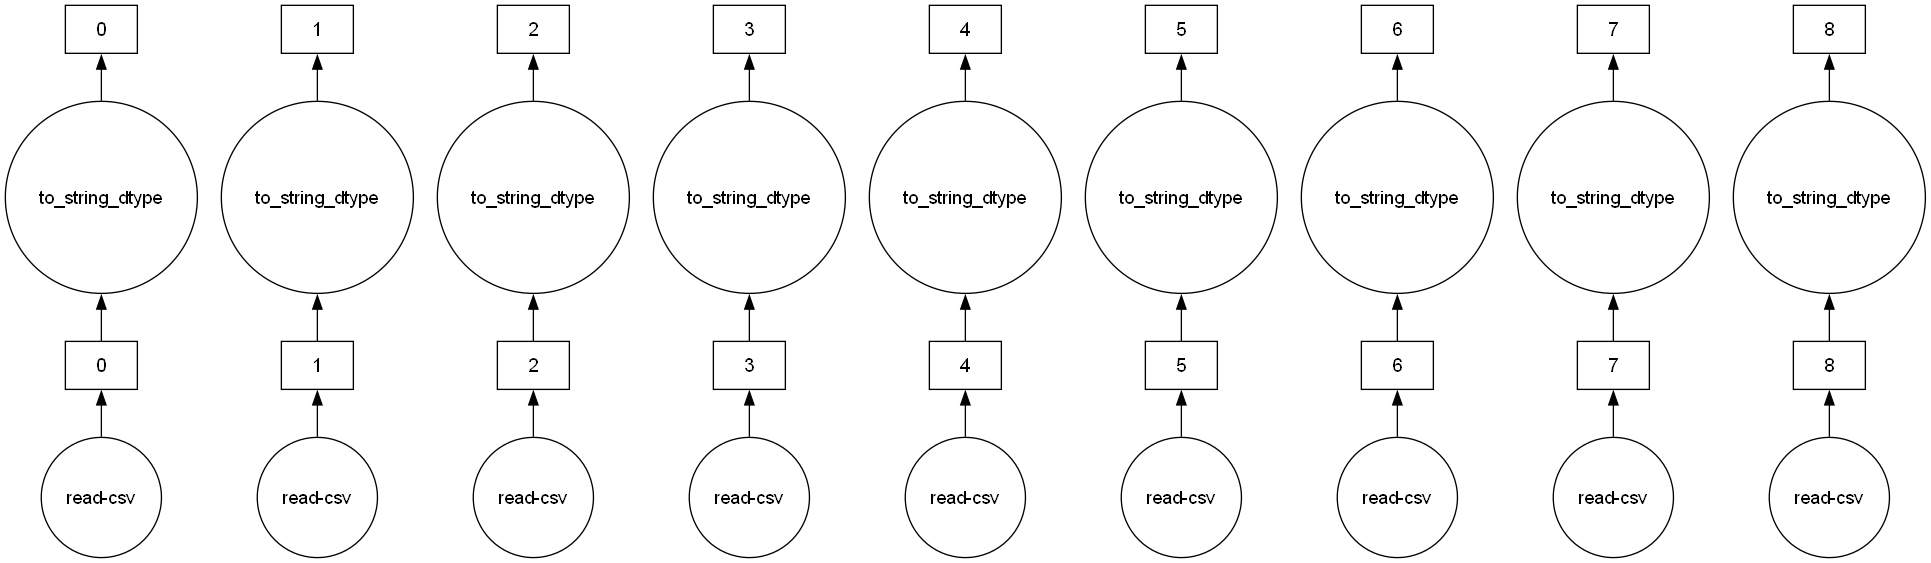

In [7]:
df_user.visualize(tasks=True)

In [8]:
# number of unique tracks in the data

unique_tracks = df_user.loc[:,'track_id'].nunique()

unique_tracks

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(3a87516))['track_id'], split_every=False)).count(), dtype=int64>

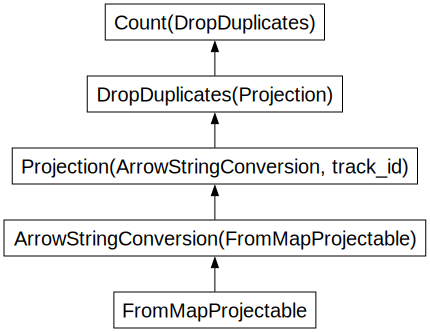

In [9]:
unique_tracks.visualize()

In [10]:
unique_tracks = unique_tracks.compute()

unique_tracks

np.int64(30459)

In [11]:
# number of unique users in the data

unique_users = df_user['user_id'].nunique()

unique_users

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(3a87516))['user_id'], split_every=False)).count(), dtype=int64>

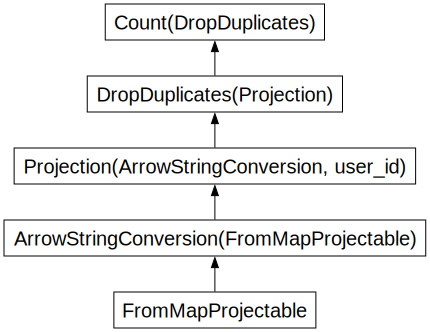

In [12]:
unique_users.visualize()

In [13]:
unique_users = unique_users.compute()

unique_users

np.int64(962037)

In [14]:
# list of unique track ids

unique_track_ids = df_user['track_id'].unique()

unique_track_ids

Dask Series Structure:
npartitions=9
    string
       ...
     ...  
       ...
       ...
Dask Name: unique, 4 expressions
Expr=Unique(frame=ArrowStringConversion(frame=FromMapProjectable(3a87516))['track_id'])

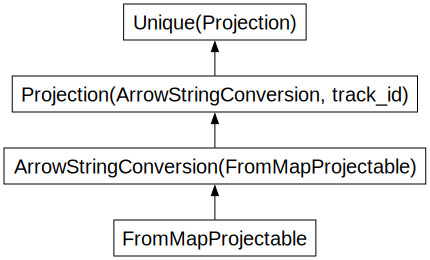

In [15]:
unique_track_ids.visualize()

In [16]:
unique_track_ids = unique_track_ids.compute()

unique_track_ids

0       TRLXSNR128F429361D
1       TRPUGUW128F426BF6F
2       TRISTWT128F1488FBB
3       TRKPWGR128E078EE06
4       TRXQJWK128F146DF76
               ...        
3348    TRXQMQE128F42268ED
3349    TRAVLOL128F428206C
3350    TRPMWJF128F4292372
3351    TRRPLPU128F4275697
3352    TRDLVZX12903CC58EB
Name: track_id, Length: 30459, dtype: string

In [17]:
len(unique_track_ids)

30459

In [18]:
# filtered songs

filtered_songs = df_songs[df_songs['track_id'].isin(unique_track_ids)]

filtered_songs

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
7,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...,01puceOqImrzSfKDAcd1Ia,"rock, alternative, indie, alternative_rock, in...",NaN,1996,264066,0.360,...,7,-9.129,1,0.0260,0.062600,0.000092,0.1720,0.317,74.807,4
9,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...,0BCPKOYdS2jbQ8iyB56Zns,"rock, alternative, indie, pop, alternative_roc...",NaN,2002,307879,0.577,...,5,-7.215,0,0.0279,0.599000,0.011500,0.1830,0.255,130.970,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50675,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...,2eIVm8hPf59hUS2PrdoGBa,"electronic, indie_pop, love",NaN,2002,285800,0.549,...,10,-7.431,1,0.0332,0.129000,0.437000,0.1220,0.551,99.679,4
50677,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...,0PG7cpyNzRehf1YNIbAsol,"alternative_rock, punk_rock",Rock,2010,183640,0.423,...,2,-4.068,1,0.1840,0.000986,0.000002,0.3790,0.224,100.080,4
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN,2008,273440,0.438,...,6,-3.062,0,0.1650,0.003120,0.000000,0.1300,0.421,166.956,4
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,...,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4


In [19]:
filtered_songs.reset_index(drop=True,inplace=True)

filtered_songs

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...,01puceOqImrzSfKDAcd1Ia,"rock, alternative, indie, alternative_rock, in...",NaN,1996,264066,0.360,...,7,-9.129,1,0.0260,0.062600,0.000092,0.1720,0.317,74.807,4
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...,0BCPKOYdS2jbQ8iyB56Zns,"rock, alternative, indie, pop, alternative_roc...",NaN,2002,307879,0.577,...,5,-7.215,0,0.0279,0.599000,0.011500,0.1830,0.255,130.970,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...,2eIVm8hPf59hUS2PrdoGBa,"electronic, indie_pop, love",NaN,2002,285800,0.549,...,10,-7.431,1,0.0332,0.129000,0.437000,0.1220,0.551,99.679,4
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...,0PG7cpyNzRehf1YNIbAsol,"alternative_rock, punk_rock",Rock,2010,183640,0.423,...,2,-4.068,1,0.1840,0.000986,0.000002,0.3790,0.224,100.080,4
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN,2008,273440,0.438,...,6,-3.062,0,0.1650,0.003120,0.000000,0.1300,0.421,166.956,4
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,...,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4


In [20]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.64,...,7,-5.829,1,0.218,0.00068,0.000003,0.049,0.642,99.211,4


In [21]:
# Ensure playcount is numeric

df_user['playcount'].dtype

dtype('int64')

In [22]:
df_user['user_id'].dtype

<StringDtype(na_value=<NA>)>

In [23]:
df_user['track_id'].dtype

<StringDtype(na_value=<NA>)>

In [24]:
# categorizing user_id and track_id
# user_id → {u1:0, u2:1, u3:2}
# “Create dictionary”

df = df_user.categorize(columns = ['user_id','track_id'])

df

,track_id,user_id,playcount
npartitions=9,,,
,category[known],category[known],int64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [25]:
# Convert user_id and track_id to numeric indices
# This is necessary for creating a sparse matrix later
# “Replace values using dictionary”
# [u1, u2, u1] → [0, 1, 0]

user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes

In [29]:
df = df.assign(
    user_idx = user_mapping,
    track_idx = track_mapping
)

df

,track_id,user_id,playcount,user_idx,track_idx
npartitions=9,,,,,
,category[known],category[known],int64,int32,int16
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


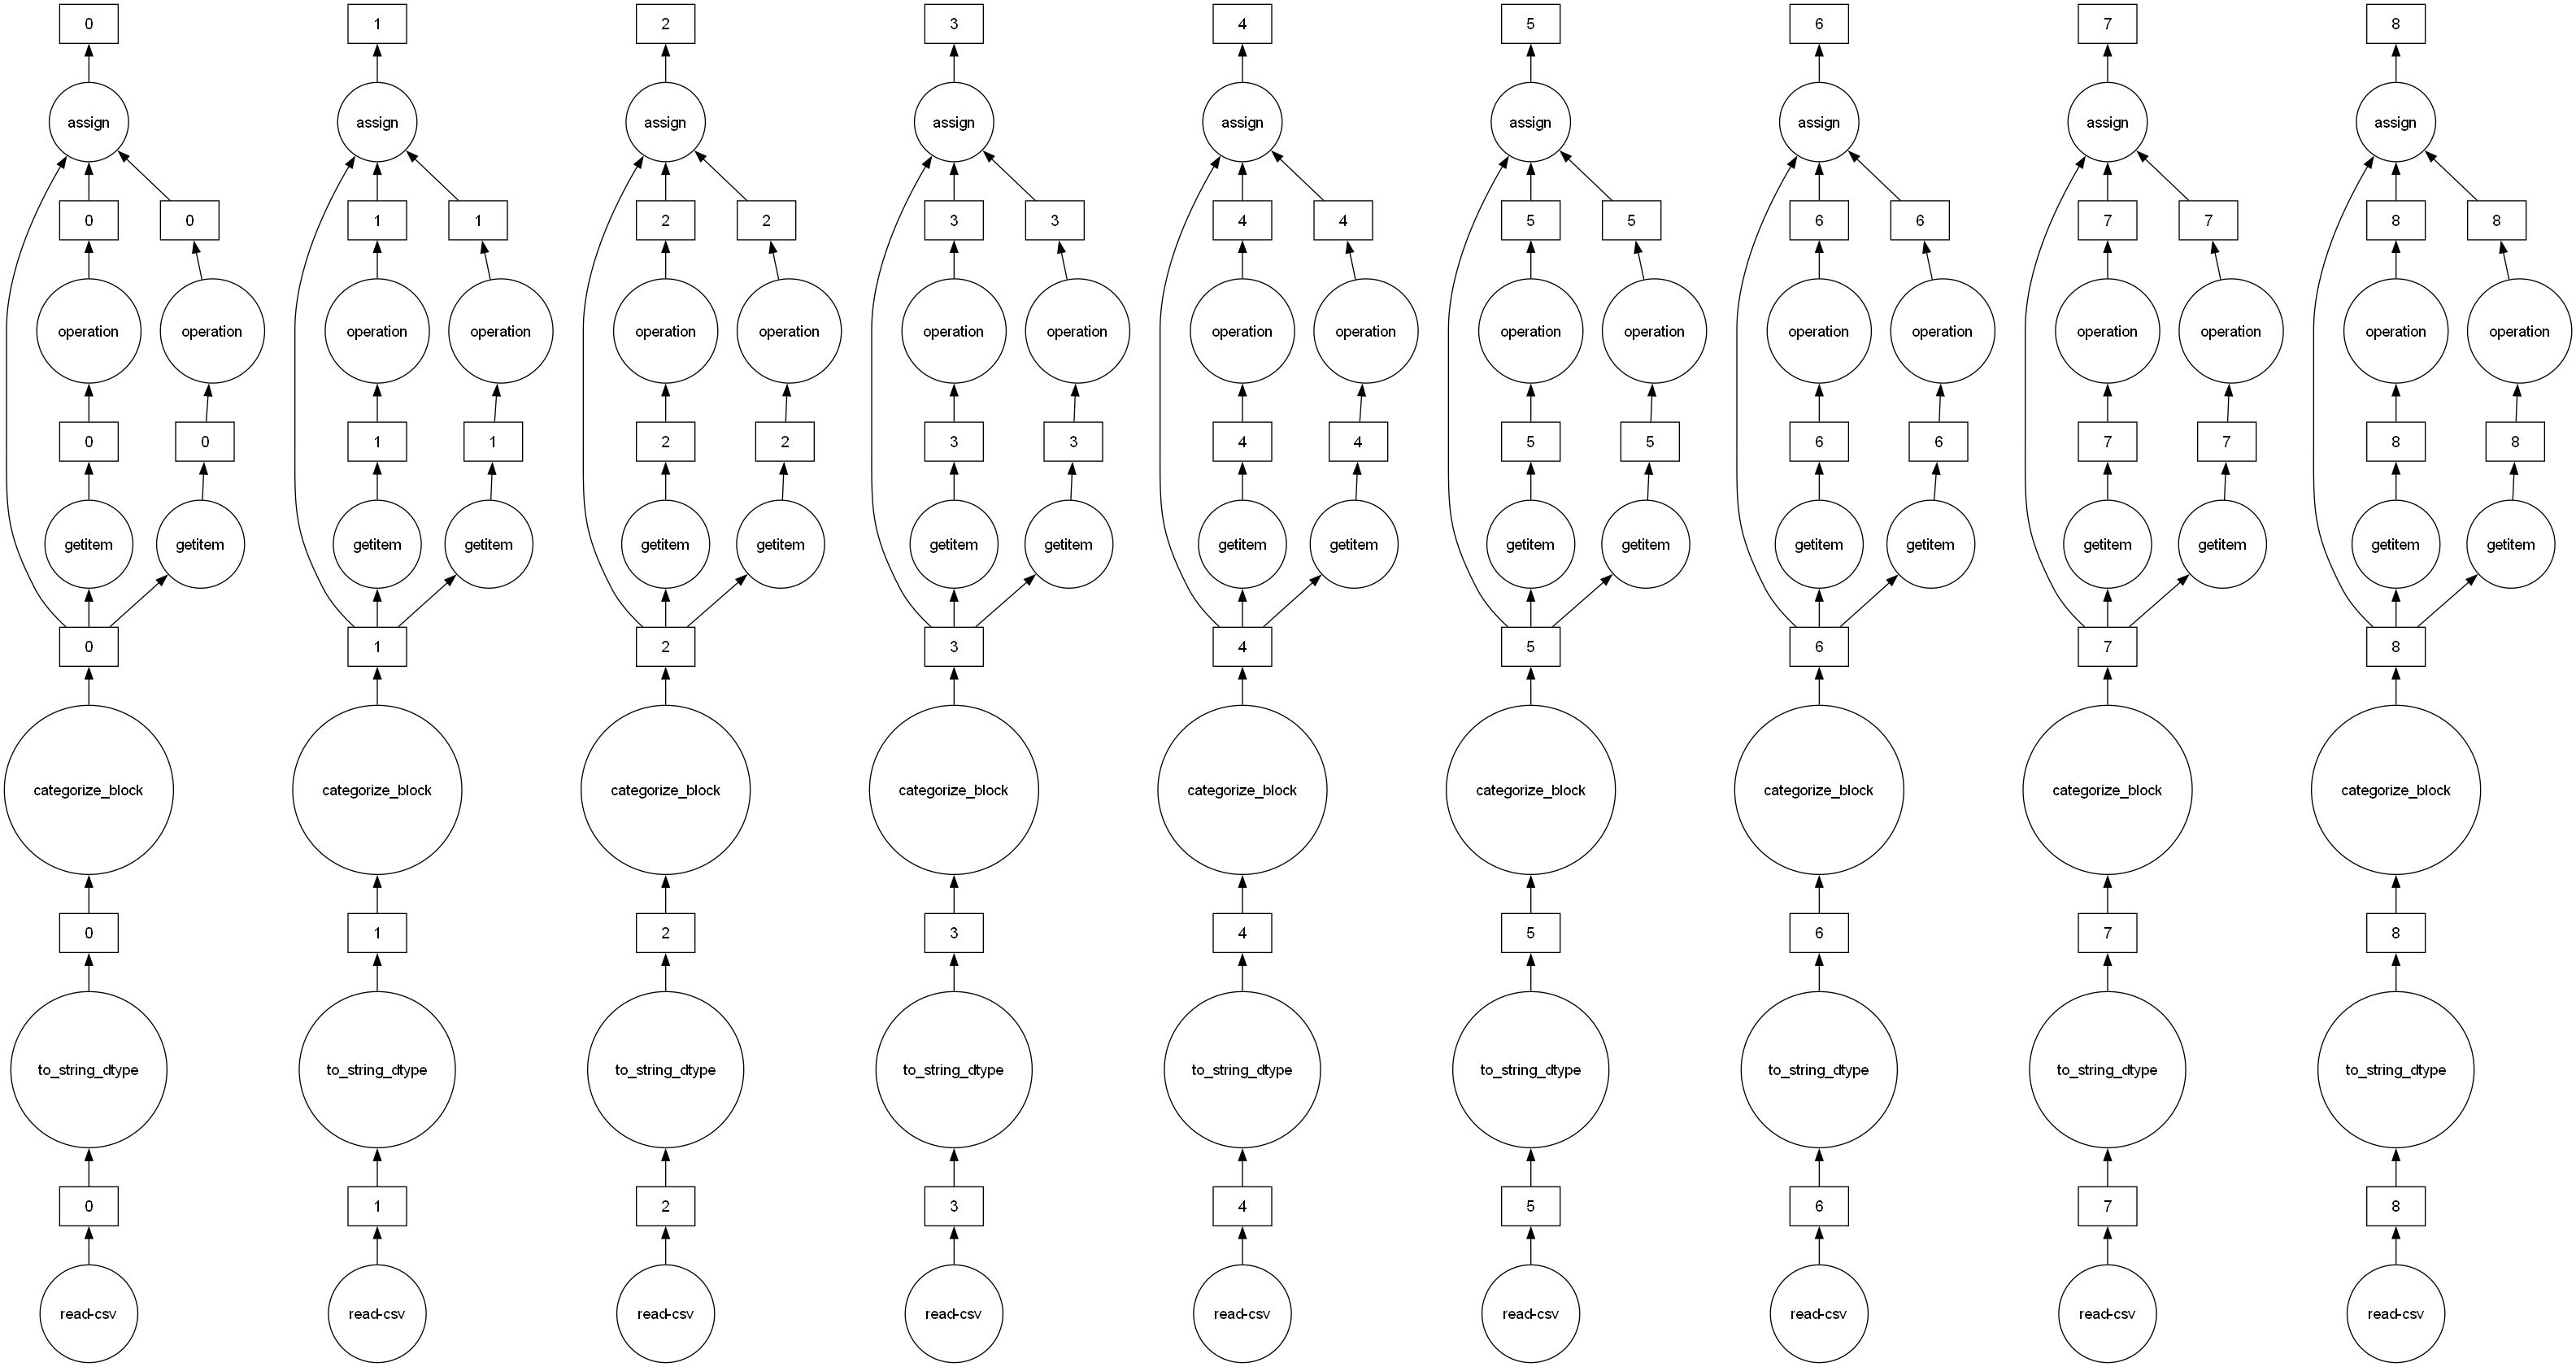

In [30]:
df.visualize(tasks=True)

In [31]:
type(df)

dask.dataframe.dask_expr._collection.DataFrame

In [32]:
# Compute the interaction matrix
# Dask doesn't support pivot tables directly, so we aggregate manually

interaction_array = df.groupby(['track_idx','user_idx'])['playcount'].sum().reset_index()

interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,int64
,...,...,...


In [33]:
type(interaction_array)

dask.dataframe.dask_expr._collection.DataFrame

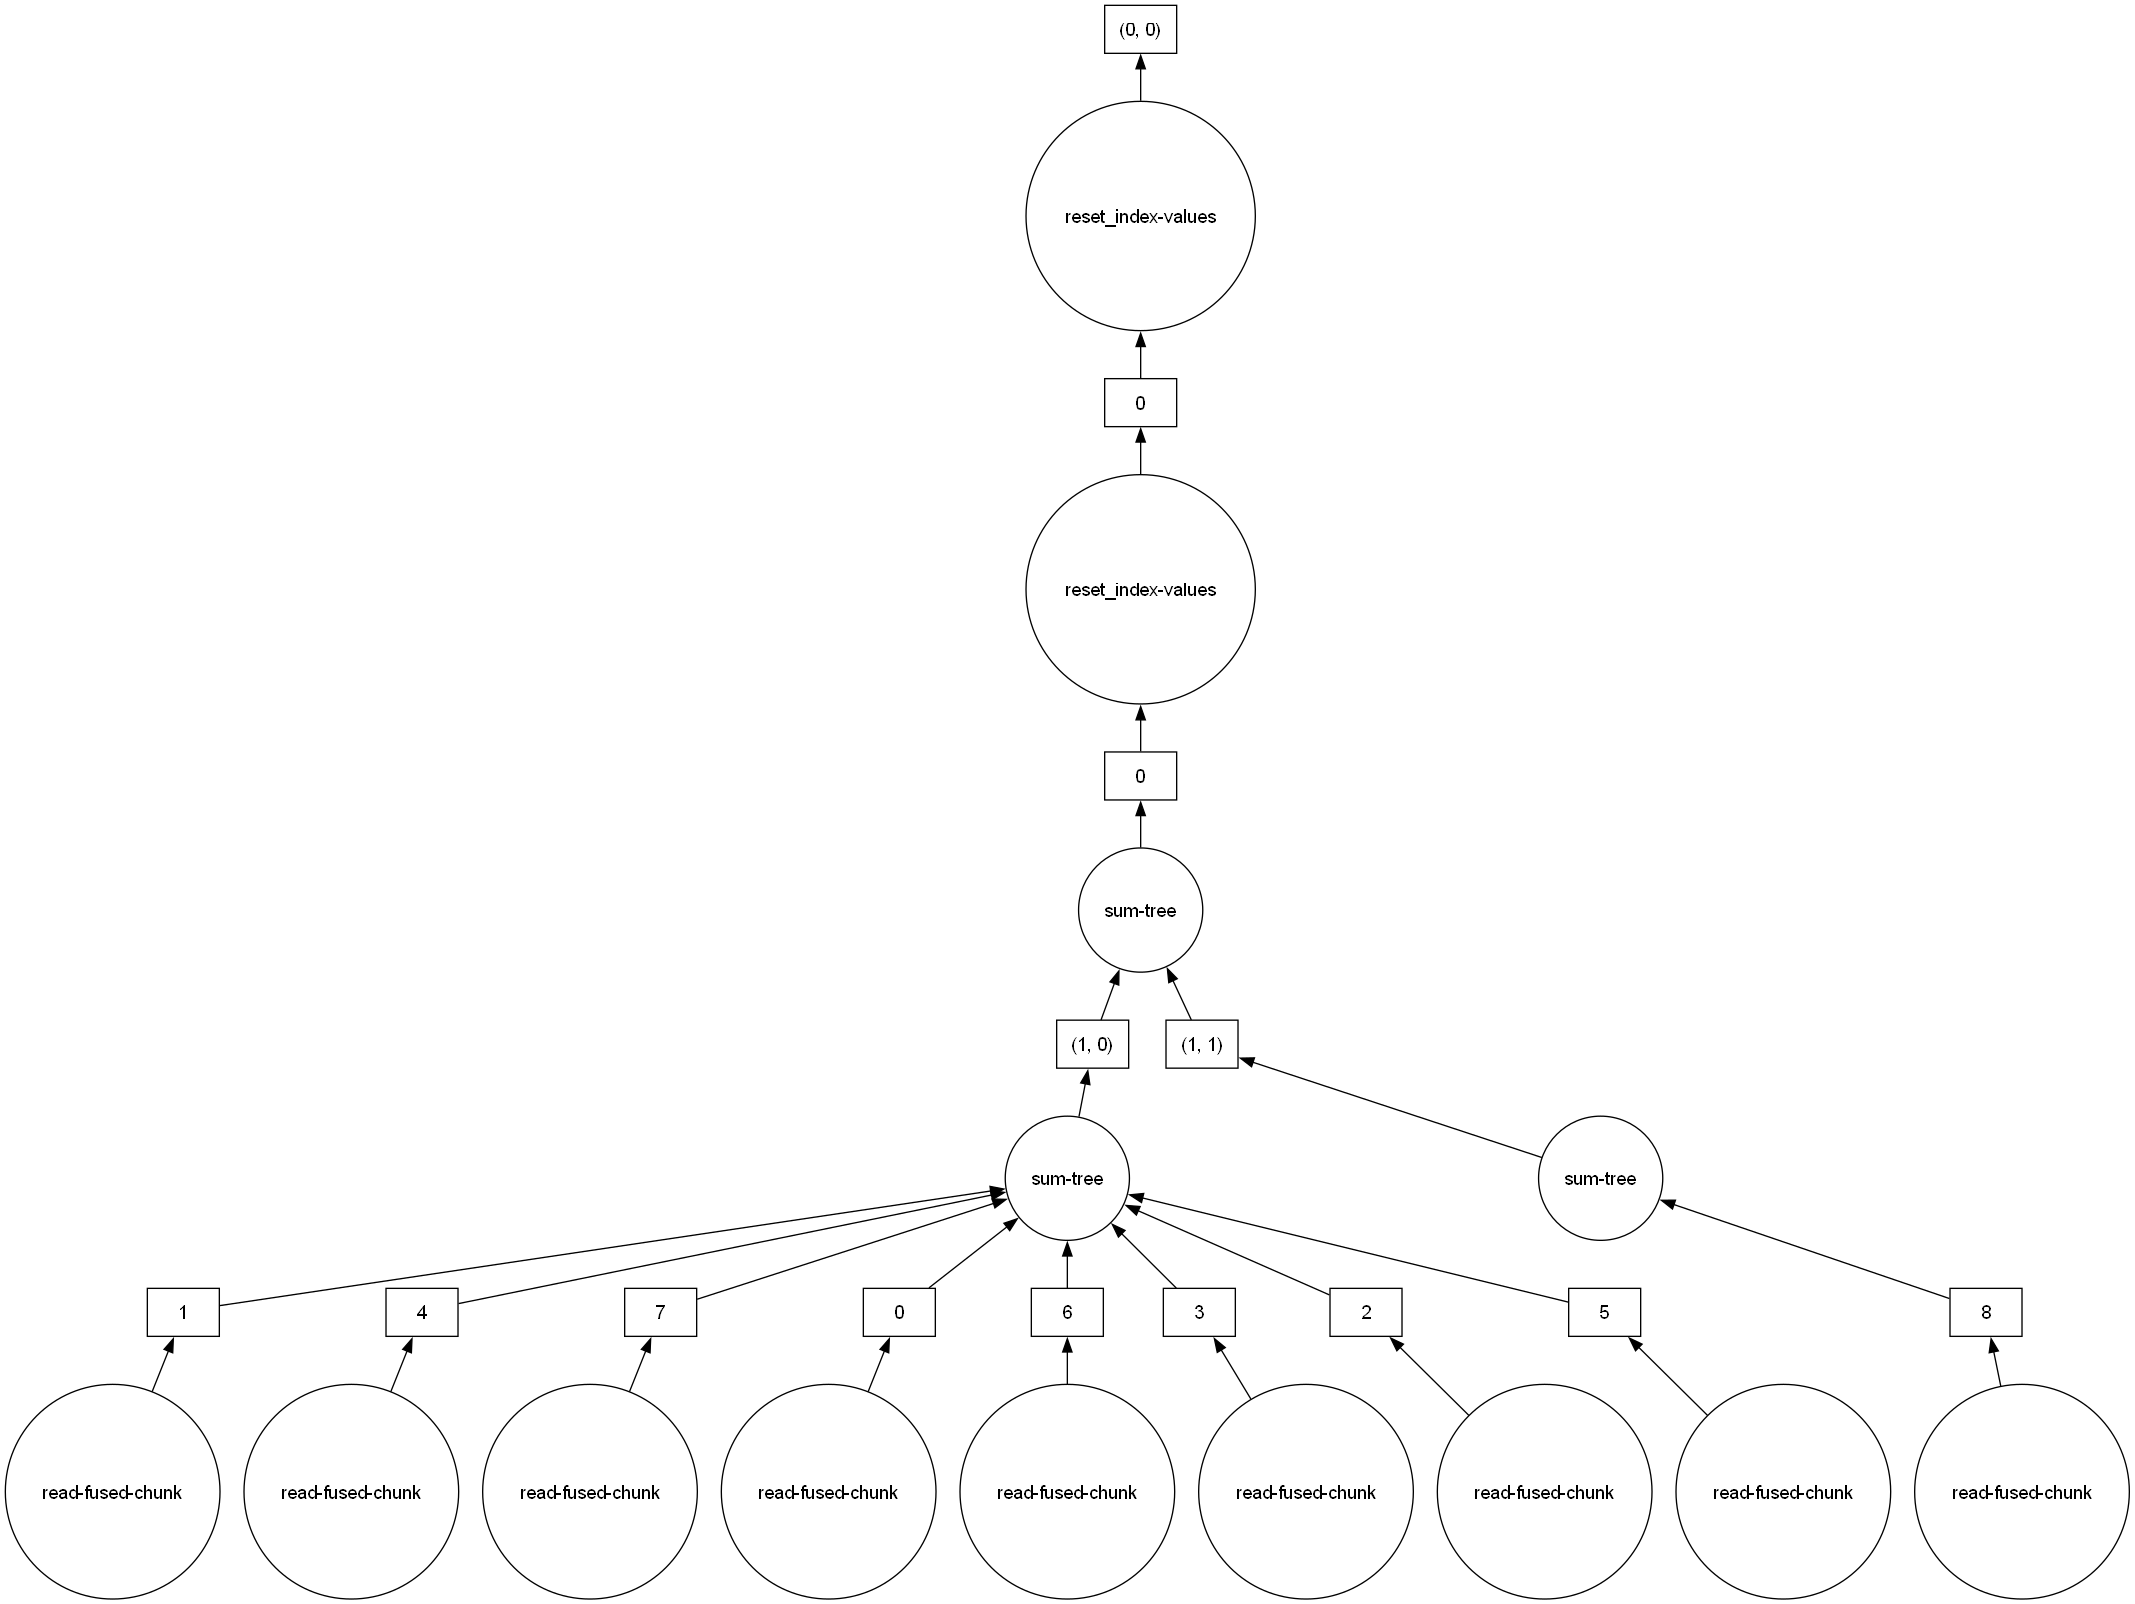

In [34]:
interaction_array.to_dask_array().visualize()

In [35]:
interaction_array = interaction_array.compute()

interaction_array

,track_idx,user_idx,playcount
0,0,15780,3
1,0,76968,1
2,0,134525,2
3,0,231541,1
4,0,305348,1
...,...,...,...
9711296,30458,902360,1
9711297,30458,913310,1
9711298,30458,922319,1
9711299,30458,925779,1


In [36]:
interaction_array.shape

(9711301, 3)

In [37]:
type(interaction_array)

pandas.DataFrame

In [38]:
# Create a sparse matrix
# Collect the data into a NumPy-friendly format

row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']

In [39]:
# Build a sparse matrix

n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csc_matrix(
    (values,(row_indices,col_indices)),
    shape = (n_tracks,n_users)
)

sparse_matrix

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 9711301 stored elements and shape (30459, 962037)>

In [40]:
# sparse matrix shape

sparse_matrix.shape

(30459, 962037)

In [41]:
# non-zero element

sparse_matrix.nnz

9711301

In [42]:
# percentage of non zero lement in sparse matrix

(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100
     

0.033141335019756815

In [43]:
# generating input array

ind = 17018

input_array = sparse_matrix[ind]

input_array

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 610 stored elements and shape (1, 962037)>

In [44]:
similarity_score = cosine_similarity(input_array,sparse_matrix)

similarity_score

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 7.20943546e-05]], shape=(1, 30459))

In [45]:
similarity_score.shape

(1, 30459)

In [46]:
np.sort(similarity_score,axis=1).ravel()[-6:][::-1]

array([1.        , 0.08225488, 0.07217127, 0.05592032, 0.05529279,
       0.05404559])

In [47]:
top_5_indexes = np.argsort(similarity_score,axis=1).ravel()[-6:][::-1]

top_5_indexes

array([17018, 24529, 28964,  3620,  9470,  7882])

In [49]:
track_id_recommendation = df['track_id'].cat.categories[top_5_indexes]

track_id_recommendation

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')

In [50]:
filtered_songs[filtered_songs['track_id'].isin(track_id_recommendation)]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.640,...,7,-5.829,1,0.2180,0.000680,0.000003,0.049,0.6420,99.211,4
8871,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...,11vlxrrjPFhb1NmNgydWAX,black_metal,NaN,2006,338733,0.533,...,11,-6.973,1,0.0360,0.000044,0.447000,0.194,0.1600,125.992,4
17287,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...,5AagWbHdT5RQz8i9JVpVS9,"electronic, house, techno, french, idm",Electronic,1999,213266,0.721,...,6,-10.269,1,0.0864,0.002320,0.886000,0.154,0.3500,158.019,4
26611,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...,6eim7EO1nw2pDbrREbzALA,drum_and_bass,Electronic,2005,387996,0.604,...,4,-7.941,0,0.0918,0.001440,0.832000,0.167,0.4080,173.950,4
26701,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...,1loN5RHuhvxF2Xb4okSvHF,drum_and_bass,Electronic,2005,380081,0.410,...,7,-5.244,1,0.0495,0.000006,0.690000,0.382,0.0397,116.004,4
27774,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...,3yCWhHYCwR1vhvBseY1c8u,progressive_rock,Rock,1993,551800,0.189,...,7,-4.488,1,0.0573,0.022100,0.222000,0.153,0.2970,92.419,4


In [173]:
def collaborative_recommendation(song_name,user_data,song_data,interaction_matrix,k=5):

    # fetch the row from song data
    song_row = song_data[song_data['name'] == song_name]
    print("The song row is :",song_row)

    # track id of input song
    input_track_id = song_row['track_id'].values.item()
    print("Input track id os the song is :",input_track_id)

    # index value of track id
    ind = np.where(user_data['track_id'].cat.categories == input_track_id)[0]
    print("Index of the song is :",ind)

    # fetch the input vector
    input_vector = interaction_matrix[ind]
    print("Input vector :",input_vector)

    # get similarity score
    similarity_score = cosine_similarity(input_vector,interaction_matrix)
    #print("Similarity score :",similarity_score[0])
    
    # index values of recommedation
    recommedation_indices = np.argsort(similarity_score.ravel())[-k-1:][::-1]
    print("recommedation_indices are :",recommedation_indices)

    # get top k recommmendation
    recommendation_track_ids = df['track_id'].cat.categories[recommedation_indices]
    print(recommendation_track_ids)
    print(len(recommendation_track_ids))

    # get top score
    top_scores = np.sort(similarity_score.ravel())[-k-1:][::-1]
    print(len(top_scores))

    # get songs and its score
    temp_df = pd.DataFrame(
        {
            'track_id' : recommendation_track_ids.tolist(),
            'score' : top_scores
        }
    )

    top_k_songs = (
        song_data
        .loc[song_data['track_id'].isin(recommendation_track_ids)]
        .merge(temp_df,on='track_id')
        .sort_values(by='score',ascending=False)
        .drop(columns=['track_id','score'])
        .reset_index(drop=True)
    )

    return top_k_songs

In [175]:
top_k_songs = collaborative_recommendation('Baby',df,filtered_songs,sparse_matrix,k=5)

top_k_songs

The song row is :                 track_id  name         artist  \
3403  TROHDEA12903CE32F1  Baby  Justin Bieber   

                                    spotify_preview_url  \
3403  https://p.scdn.co/mp3-preview/150f98af871ed170...   

                  spotify_id            tags genre  year  duration_ms  \
3403  04ZliB3T4zKREejZTpk0CF  pop, rnb, love   NaN  2010       214480   

      danceability  ...  key  loudness  mode  speechiness  acousticness  \
3403         0.687  ...    5    -5.373     0        0.144         0.045   

      instrumentalness  liveness  valence   tempo  time_signature  
3403               0.0    0.0938    0.491  65.028               4  

[1 rows x 21 columns]
Input track id os the song is : TROHDEA12903CE32F1
Index of the song is : [16870]
Input vector : <Compressed Sparse Column sparse matrix of dtype 'int64'
	with 17 stored elements and shape (1, 962037)>
  Coords	Values
  (0, 57680)	1
  (0, 78489)	1
  (0, 126058)	1
  (0, 142912)	4
  (0, 152596)	1
  (0, 17842

,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Baby,Justin Bieber,https://p.scdn.co/mp3-preview/150f98af871ed170...,04ZliB3T4zKREejZTpk0CF,"pop, rnb, love",NaN,2010,214480,0.687,0.841,5,-5.373,0,0.1440,0.04500,0.000000,0.0938,0.4910,65.028,4
1,Present of Future End,The Most Serene Republic,https://p.scdn.co/mp3-preview/e9c90b99a29806f1...,0HT7wU3YKwQskOYUjpsqZI,"indie, love",Rock,2007,324640,0.394,0.772,0,-7.293,1,0.0351,0.00399,0.627000,0.0902,0.3000,144.057,4
2,Lime Tree,Bright Eyes,https://p.scdn.co/mp3-preview/2616738f4adc8f10...,0vbdsjmVzoJDFTKqa1Dz6W,"indie, folk, singer_songwriter, acoustic, indi...",Rock,2007,353773,0.462,0.196,7,-11.858,1,0.0262,0.76400,0.000002,0.0906,0.1650,100.049,4
3,Í Gær,Sigur Rós,https://p.scdn.co/mp3-preview/dfc24b1bff0eadab...,2PCJnlB0swwBjk9xBYSJtI,"alternative, ambient, post_rock",NaN,2007,386693,0.382,0.423,4,-8.281,0,0.0290,0.13300,0.764000,0.0832,0.0313,105.470,4
4,Shaker,The Wretch,https://p.scdn.co/mp3-preview/12a6b2ed848a0c03...,2Vitv3PVeoSn5Bjh69zh40,"metal, hardcore, classical, gothic",NaN,2004,245493,0.679,0.920,5,-6.761,0,0.2450,0.07640,0.773000,0.0755,0.5070,159.996,4
5,Melankoli,Lulu Rouge,https://p.scdn.co/mp3-preview/fe8da49bac7e1711...,0BjCuWvriUVI6pkFzQhyAP,"chillout, downtempo",Electronic,2010,291720,0.687,0.218,9,-18.973,1,0.0342,0.61700,0.823000,0.1090,0.3780,120.015,4
